---
### Imports


In [26]:
from excel_io import dfs_from_excel, Input
from structure_io import read_structure
from dataclasses import fields
import numpy as np
import matplotlib.pyplot as plt

---
### Input Values
This is where the user defines all input values. The user doesn't need to modify any value after this section of the notebook.

In [27]:
dfs = dfs_from_excel("../Excel/2026_C_SE_PROPELLANT_BUDGET_CDR.xlsx")
ipt = Input.from_dfs(dfs, row=3) #so this makes us run cofig 4

for f in fields(ipt): 
    globals()[f.name] = getattr(ipt, f.name) #creates a variable called f.name and stores the value of ipt.f.name in it
    print(f"{f.name}:", getattr(ipt, f.name))

struct = read_structure("structure_inputs.xlsx")

Version: CH
savefiles: True
N_points: 1000
run_environment: True
write_to_file: False
out_filename: output_CH.csv
r_int: 0.115
h_cyl: 0.3851008075
h_cap: 0.05
alpha: 6
beta: 6
l_rail: 11.65
g: 9.81
F_HD_break: 3300
mu: 0.5
m_dry: 95.66
m_additions: 0
OF_ratio: 1.5
ISP: 240
Thrust: 6000
Total_impulse: 36167
fraction_film_cooling: 0.075
mass_flow_rate: 2.54841997961264
mass_flow_rate_ethanol: 1.019367991845056
mass_flow_rate_ethanol_ignition: 0
mass_flow_rate_film_cooling: 0.0764525993883792
mass_flow_rate_ethanol_burn: 1.0958205912334351
mass_flow_rate_lox_boil_off: 0.001
mass_flow_rate_lox_ignition: 4.362
mass_flow_rate_lox_prechill: 4.362
mass_flow_rate_lox_burn: 1.529051987767584
burn_time: 6.027833333333334
propellant_mass: 15.361450900441724
hold_time: 300
prechill_time: 0.2
ignition_delay: -0.05
ramp_up_time: 0.4
cutoff_time: 0.025
ramp_down_time: 0.2
m_fuel_delay: 0
m_fuel_cutoff: 0.027395514780835878
m_fuel_burn: 6.605423887189942
m_fuel_end: 0.43239551478083593
m_fuel_total: 7.

---
### Thrust Curve
This is where values related to the thrust curve are computed, and where the thrust curve itself is visualized.

The values taken from https://docs.google.com/spreadsheets/d/1W7kPz_u5sJc_arKdKixkTv66EgacR5xaWVpI8u8FtFw/edit?gid=1873614830#gid=1873614830 are used to generate the thrust curve over time.

=== Computed Results ===
Total Impulse: 35566.92 N·s
Ramp-up slope: 15000.00 N/s
Derating slope: 0.00 N/s
Shutdown slope: -30000.00 N/s


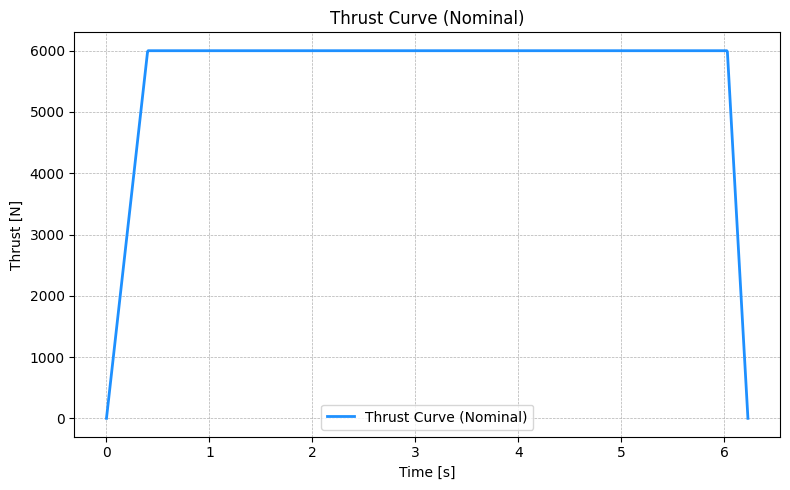

In [28]:
# --- Compute slopes for each linear segment ---
slope_ramp_up = F_full_thrust / t_full_thrust
slope_derating = (F_ramp_down - F_derating) / (t_ramp_down - t_derating)
slope_shutdown = (F_shutdown - F_ramp_down) / (t_shutdown - t_ramp_down)

# --- Build time vector and thrust profile ---
t_total = np.linspace(0, t_shutdown, N_points)
F = np.zeros_like(t_total)

for i, t in enumerate(t_total):
    if t <= t_full_thrust:
        # Ramp-up phase
        F[i] = slope_ramp_up * t
    elif t <= t_derating:
        # Constant thrust phase
        F[i] = F_derating
    elif t <= t_ramp_down:
        # Derating phase (linear decrease)
        F[i] = F_derating + slope_derating * (t - t_derating)
    else:
        # Shutdown phase (linear decrease to zero)
        F[i] = F_ramp_down + slope_shutdown * (t - t_ramp_down)

# --- Compute total impulse (area under curve) ---
total_impulse = np.trapezoid(F, t_total)

# --- Print results ---
print("=== Computed Results ===")
print(f"Total Impulse: {total_impulse:.2f} N·s")
print(f"Ramp-up slope: {slope_ramp_up:.2f} N/s")
print(f"Derating slope: {slope_derating:.2f} N/s")
print(f"Shutdown slope: {slope_shutdown:.2f} N/s")

# --- Plot thrust curve ---
plt.figure(figsize=(8,5))
plt.plot(t_total, F, label='Thrust Curve (Nominal)', color='dodgerblue', linewidth=2)
plt.title('Thrust Curve (Nominal)')
plt.xlabel('Time [s]')
plt.ylabel('Thrust [N]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

---
### Hold-Down and Launch-rail
##### Hold-Down static equations
This is where all quantites related to the hold down calculations are computed.

The equations that relate the hold-down force and the rail button force are:

$$
\boxed{
F_{HD} = \frac{F_{eng} - F_{weight}\left(\cos\alpha - \mu\sin\alpha\right)}
               {\cos\beta - \mu\sin\beta}
}
$$

$$
\boxed{
F_{rrb} = \frac{F_{eng}\sin\beta + F_{weight}\sin(\alpha - \beta)}
               {\cos\beta - \mu\sin\beta}
}
$$

and these equations can be calculated at each time step with the corresponding thrust in order to determine at which time the hold-down breaks and the launch vehicle starts moving.

##### Launch Rail Kinematic Equations
The following equation describes the rocket’s motion along the launch rail:

$$
\boxed{
    a_{LV} = \frac{F_{eng} - m_{wet} g \cos\alpha}{m_{wet}}
}
$$

and this equation can be integrated over time until the launch vehicle has cleared the launch rail in order to obtain the exit velocity.

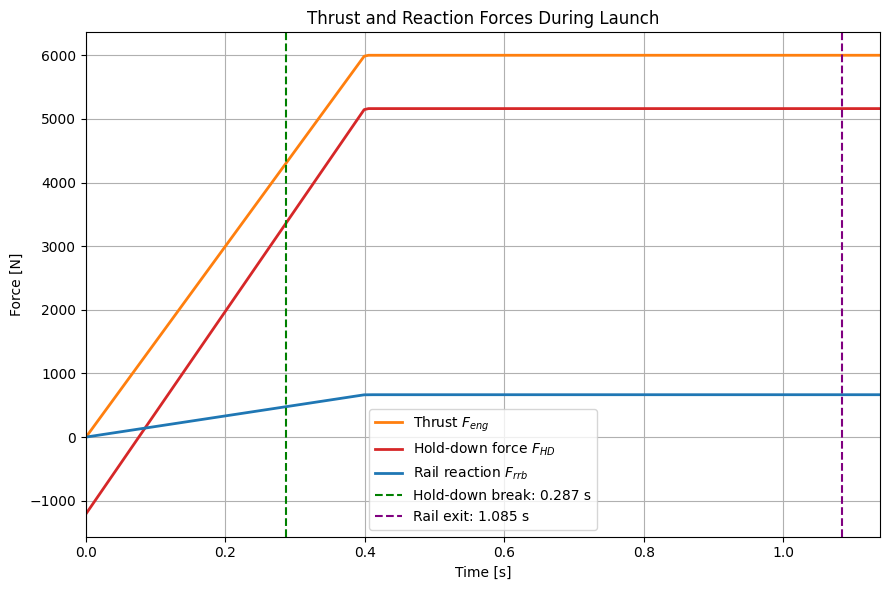

=== Launch Dynamics Summary ===
Hold-down breaks at t = 0.287 s
Rocket clears launch rail at t = 1.085 s
Exit velocity = 30.34 m/s


In [29]:
# Variables used in formulas
## Forces
F_eng = F
m_dry = m_dry + m_additions
m_wet = m_dry + m_ox_burn + m_ox_end + m_fuel_burn + m_fuel_end + m_n2_copv*2 # Already removed all losses before ignition
W = m_wet * g

## Angles
alpha = np.deg2rad(alpha)
beta = np.deg2rad(beta)

## Time
t_array = t_total
dt = np.mean(np.diff(t_array))

# 1. Compute reaction forces at each time step
denominator = np.cos(beta) - mu * np.sin(beta)
F_HD = (F_eng - W * (np.cos(alpha) - mu * np.sin(alpha))) / denominator
F_rrb = (F_eng * np.sin(beta) + W * np.sin(alpha - beta)) / denominator

# 2. Identify when hold-down force exceeds the break threshold
if F_HD_break > 0:
    mask_break = F_HD >= F_HD_break
    if np.any(mask_break):
        idx_break = np.argmax(mask_break)
        t_break = t_array[idx_break]
    else:
        raise ValueError("Hold-down threshold not reached during the burn !")
else:
    print("No hold-down mechanism !")
    idx_break = 0
    t_break = t_array[idx_break]

# 3. Launch vehicle kinematics after release
## Compute acceleration
a_LV = (F_eng - m_wet * g * np.cos(alpha)) / m_wet
a_LV[a_LV < 0] = 0  # rocket can't accelerate backward along rail

## Integrate velocity and displacement over time (from t_break onwards)
v = np.zeros_like(a_LV)
s = np.zeros_like(a_LV)

for i in range(idx_break + 1, len(t_array)):
    v[i] = v[i-1] + a_LV[i-1] * dt
    s[i] = s[i-1] + v[i-1] * dt

## Find when rocket clears the rail
mask_exit = s >= l_rail
if np.any(mask_exit):
    idx_exit = np.argmax(mask_exit)
    t_exit = t_array[idx_exit]
    v_exit = v[idx_exit]
else:
    raise ValueError("Rocket did not clear the rail within thrust duration !")

# 4. Plot results
plt.figure(figsize=(9,6))

plt.plot(t_array, F_eng, label='Thrust $F_{eng}$', color='tab:orange', linewidth=2)
plt.plot(t_array, F_HD, label='Hold-down force $F_{HD}$', color='tab:red', linewidth=2)
plt.plot(t_array, F_rrb, label='Rail reaction $F_{rrb}$', color='tab:blue', linewidth=2)

# Highlight key events
plt.axvline(t_break, color='green', linestyle='--', label=f'Hold-down break: {t_break:.3f} s')
plt.axvline(t_exit, color='purple', linestyle='--', label=f'Rail exit: {t_exit:.3f} s')

plt.title('Thrust and Reaction Forces During Launch')
plt.xlabel('Time [s]')
plt.ylabel('Force [N]')
plt.xlim(0, t_exit * 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Print summary ---
print("=== Launch Dynamics Summary ===")
print(f"Hold-down breaks at t = {t_break:.3f} s")
print(f"Rocket clears launch rail at t = {t_exit:.3f} s")
print(f"Exit velocity = {v_exit:.2f} m/s")

---
### Propellant Masses

This section computes the propellant tank geometry, propellant volumes, and mass depletion profiles needed to generate the `.eng` files.

**Key equations:**

- Equivalent cylindrical height:  
  $h_{eq} = h_{cyl} + \frac{4}{3}h_{cap}$

- Heights and centers of mass:  
  $h_{free} = \frac{V_{free}}{A_{tank}}$  $h_{fixed} = \frac{V_{fixed}}{A_{tank}}$  $z_{COM} = \frac{h_{fixed}}{2}$

- Mass flow rate proportional to thrust:  
  $\dot{m}(t) = m_{free} \frac{F(t)}{\int F(t)\,dt}$

- Remaining mass:  
  $m_{rem}(t) = m_{free} - \int_0^t \dot{m}(\tau)\,d\tau$

The code computes:
1. Equivalent tank geometry and ullage for both propellants.  
2. Free and fixed masses, volumes, and COM positions.  
3. Propellant depletion curves following the thrust profile.  
4. The time when the **hold-down breaks** and the **mass consumed** before that moment.  
5. Plots of **mass flow rate** and **total remaining mass** (fixed + free) vs. time, with the hold-down break marked as a vertical line.


=== Equivalent Cylindrical Tank Geometry ===
Equivalent cylindrical height: 385.10 [mm]
Tank total volume: 16.000 [L]

=== Fuel ===
Free volume: 8.155 [L] | Position of free volume bottom: 12.848 [mm] | Height of free volume: 196.277 [mm]
Fixed volume: 0.534 [L] | Fixed volume CoM position from tank bottom: 6.424 [mm] | Fixed volume mass: 0.432 [kg]
Total volume: 8.689 [L] | Total volume CoM position from tank bottom: 104.563 [mm] | Height of total volume: 209.126 [mm]
Ullage volume initial: 7.311 [L] | Ullage percentage: 45.6958 [%]
Ullage volume flight: 7.311 [L] | Ullage percentage: 45.6958 [%]

=== Oxidizer ===
Free volume: 7.987 [L] | Position of free volume bottom: 12.034 [mm] | Height of free volume: 192.235 [mm]
Fixed volume: 0.500 [L] | Fixed volume CoM position from tank bottom: 6.017 [mm] | Fixed volume mass: 0.577 [kg]
Total volume: 9.692 [L] | Total volume CoM position from tank bottom: 116.635 [mm] | Height of total volume: 233.271 [mm]
Ullage volume initial: 6.308 [L] | 

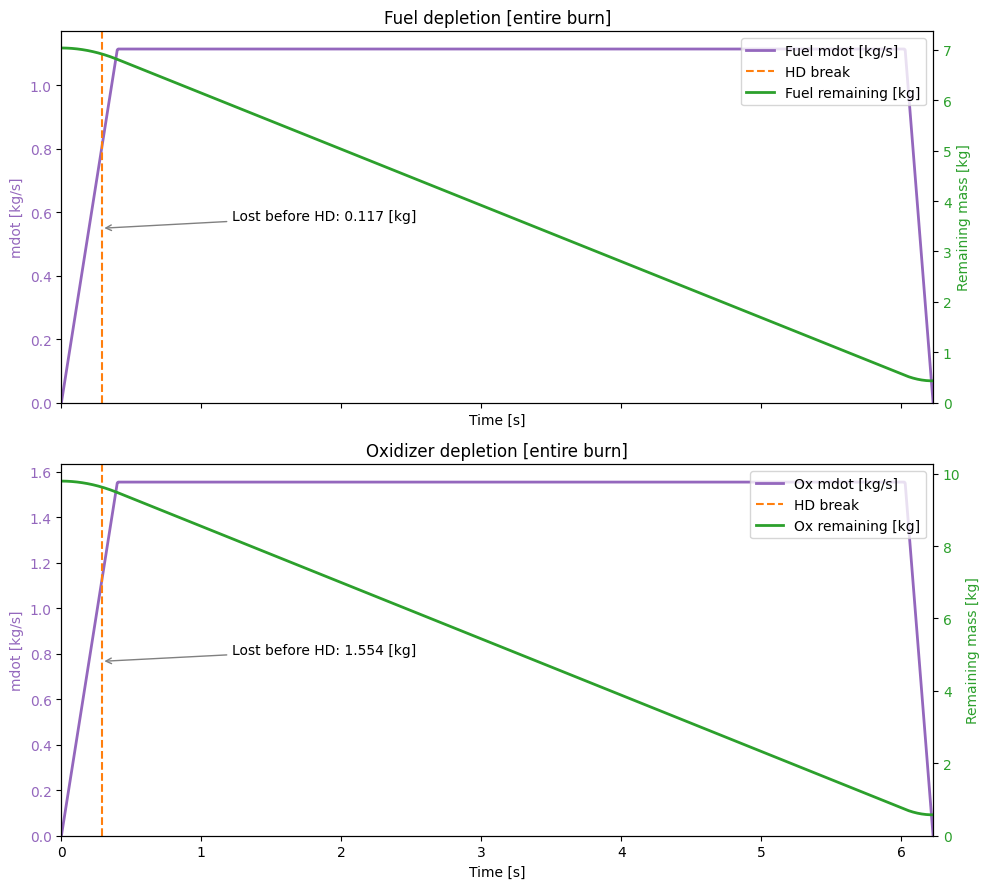

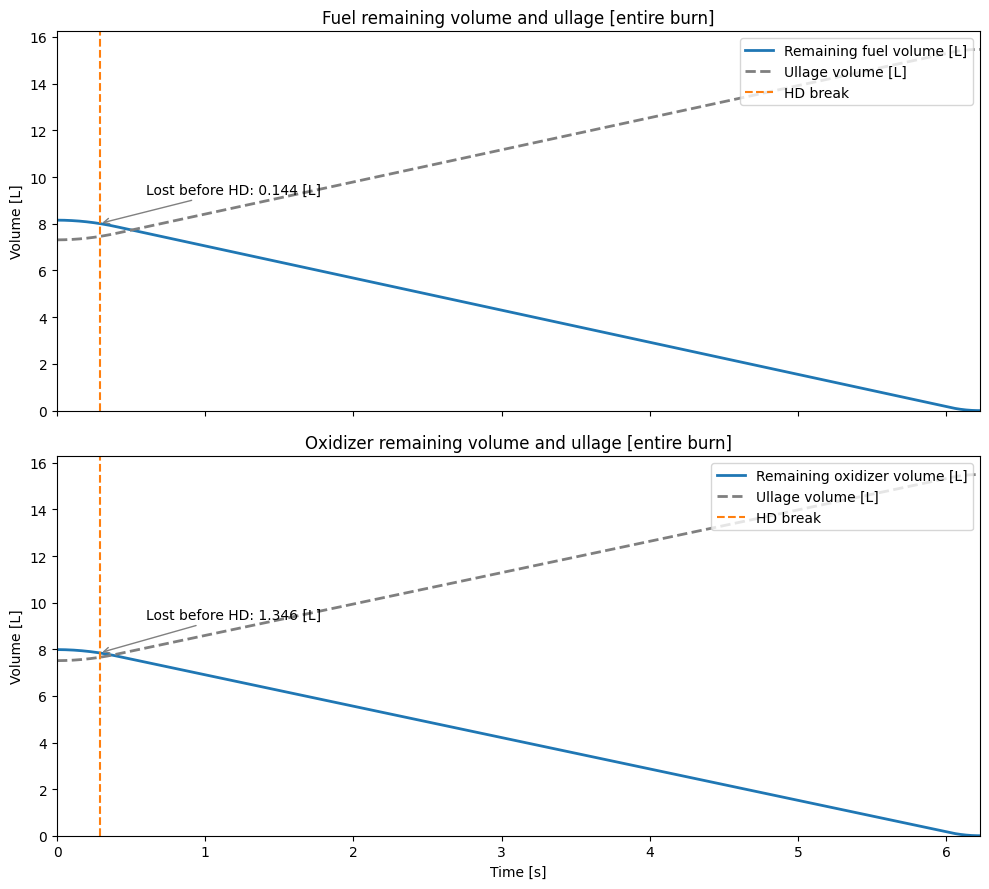

In [30]:
# Compute equivalent cylindrical height
A_tank = np.pi * (r_int**2)
h_eq = h_cyl #+ (4/3) * h_cap

# Compute equivalent total tank volume
V_tank_total = A_tank * h_eq

# Compute fixed and free volumes for each propellant
## Fuel
V_fuel_free = m_fuel_burn / rho_fuel
V_fuel_fixed = m_fuel_end / rho_fuel
V_fuel_total = m_fuel_total / rho_fuel

## Oxidizer
V_ox_free = m_ox_burn / rho_ox
V_ox_fixed = m_ox_end / rho_ox
V_ox_total = m_ox_total / rho_ox

# Compute equivalent heights
h_fuel_free = V_fuel_free / A_tank
h_fuel_fixed = V_fuel_fixed / A_tank
h_fuel_total = V_fuel_total / A_tank

h_ox_free = V_ox_free / A_tank
h_ox_fixed = V_ox_fixed / A_tank
h_ox_total = V_ox_total / A_tank

# Heights of interest
## Fixed mass (liquid remaining at bottom)
z_fuel_fixed_COM = h_fuel_fixed / 2
z_ox_fixed_COM = h_ox_fixed / 2

## Free mass bottom position
z_fuel_free_bottom = h_fuel_fixed
z_ox_free_bottom = h_ox_fixed

## Total mass
z_fuel_total_COM = h_fuel_total / 2
z_ox_total_COM = h_ox_total / 2

z_fuel_total_bottom = h_fuel_total
z_ox_total_bottom = h_ox_total

# Display results
print("=== Equivalent Cylindrical Tank Geometry ===")
print(f"Equivalent cylindrical height: {1000*h_eq:.2f} [mm]")
print(f"Tank total volume: {1000*V_tank_total:.3f} [L]")

print("\n=== Fuel ===")
print(f"Free volume: {1000*V_fuel_free:.3f} [L] | Position of free volume bottom: {1000*z_fuel_free_bottom:.3f} [mm] | Height of free volume: {1000*h_fuel_free:.3f} [mm]")
print(f"Fixed volume: {1000*V_fuel_fixed:.3f} [L] | Fixed volume CoM position from tank bottom: {1000*z_fuel_fixed_COM:.3f} [mm] | Fixed volume mass: {m_fuel_end:.3f} [kg]")
print(f"Total volume: {1000*V_fuel_total:.3f} [L] | Total volume CoM position from tank bottom: {1000*z_fuel_total_COM:.3f} [mm] | Height of total volume: {1000*z_fuel_total_bottom:.3f} [mm]")
print(f"Ullage volume initial: {1000*(V_tank_total - V_fuel_total):.3f} [L] | Ullage percentage: {(V_tank_total - V_fuel_total)/V_tank_total*100:.4f} [%]")
print(f"Ullage volume flight: {1000*(V_tank_total - V_fuel_fixed - V_fuel_free):.3f} [L] | Ullage percentage: {(V_tank_total - V_fuel_fixed - V_fuel_free)/V_tank_total*100:.4f} [%]")

print("\n=== Oxidizer ===")
print(f"Free volume: {1000*V_ox_free:.3f} [L] | Position of free volume bottom: {1000*z_ox_free_bottom:.3f} [mm] | Height of free volume: {1000*h_ox_free:.3f} [mm]")
print(f"Fixed volume: {1000*V_ox_fixed:.3f} [L] | Fixed volume CoM position from tank bottom: {1000*z_ox_fixed_COM:.3f} [mm] | Fixed volume mass: {m_ox_end:.3f} [kg]")
print(f"Total volume: {1000*V_ox_total:.3f} [L] | Total volume CoM position from tank bottom: {1000*z_ox_total_COM:.3f} [mm] | Height of total volume: {1000*z_ox_total_bottom:.3f} [mm]")
print(f"Ullage volume initial: {1000*(V_tank_total - V_ox_total):.3f} [L] | Ullage percentage: {(V_tank_total - V_ox_total)/V_tank_total*100:.4f} [%]")
print(f"Ullage volume flight: {1000*(V_tank_total - V_ox_fixed - V_ox_free):.3f} [L] | Ullage percentage: {(V_tank_total - V_ox_fixed - V_ox_free)/V_tank_total*100:.4f} [%]")

print("\n=== Pressurant ===")
print(f"Fixed volume mass: {2 * m_n2_copv:.3f} [kg]\n")

# --------------------- Mass Depletion Curves --------------------------------

# Helper: compute mdot and remaining mass over the full time array
def compute_full_depletion(free_mass, rho, t, F):
    """
    Compute mdot(t) and remaining mass mrem(t) for t starting at 0 across full burn.
    mdot proportional to F(t) and normalized so integral mdot dt = free_mass.
    Returns mdot, mrem, consumed (cumulative consumed mass).
    """
    integral_F = np.trapezoid(F, t)
    if integral_F <= 0:
        mdot = np.zeros_like(F)
    else:
        mdot = free_mass * (F / integral_F)
    dt = np.diff(t, prepend=t[0])  # first dt=0
    consumed = np.cumsum(mdot * dt)
    mrem = np.maximum(free_mass - consumed, 0.0)
    Vrem = mrem / rho # calulates remaining propellant volume 
    return mdot, mrem, consumed, Vrem

# Compute for fuel and oxidizer
free_fuel = float(m_fuel_burn)     # fuel free mass [kg]
free_ox   = float(m_ox_burn)       # oxidizer free mass [kg]

mdot_fuel, mrem_fuel, consumed_fuel, Vrem_fuel = compute_full_depletion(free_fuel, rho_fuel, t_total, F_eng)
mdot_ox,   mrem_ox,   consumed_ox, Vrem_ox   = compute_full_depletion(free_ox, rho_ox, t_total, F_eng)

# Determine index/time of hold-down break (first index where t >= t_break)
idx_break = np.searchsorted(t_total, t_break, side='left')
if idx_break >= len(t_total):
    raise RuntimeError("t_break lies beyond the available time array.")

t_at_break = t_total[idx_break]
mass_lost_fuel_before_break = consumed_fuel[idx_break] + m_fuel_delay
mass_lost_ox_before_break   = consumed_ox[idx_break] + m_ox_boil_off + m_ox_prechill + m_ox_delay

# Compute total remaining mass (fixed + free)
mrem_fuel_total = mrem_fuel + m_fuel_end # m_fuel_end has m_fuel_cutoff in it
mrem_ox_total   = mrem_ox + m_ox_end

# Print summary
print("=== Mass depletion summary (over entire burn) ===")
print(f"Fuel free mass: {free_fuel:.3f} [kg]")
print(f"Ox free mass  : {free_ox:.3f} [kg]")
print(f"Hold-down breaks at t = {t_at_break:.3f} [s] (index {idx_break})")
print(f"Fuel mass lost BEFORE break = {mass_lost_fuel_before_break:.3f} [kg]")
print(f"Oxidizer mass lost BEFORE break = {mass_lost_ox_before_break:.3f} [kg]\n")

# ------------------ Plotting ------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
plt.subplots_adjust(hspace=0.35)

# Fuel subplot
ax = axes[0]
ax.plot(t_total, mdot_fuel, label="Fuel mdot [kg/s]", color="tab:purple", linewidth=2)
ax.set_ylabel("mdot [kg/s]", color="tab:purple")
ax.tick_params(axis="y", labelcolor="tab:purple")
ax.set_ylim(bottom=0)

ax2 = ax.twinx()
ax2.plot(t_total, mrem_fuel_total, label="Fuel remaining [kg]", color="tab:green", linewidth=2)
ax2.set_ylabel("Remaining mass [kg]", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.set_ylim(bottom=0)

ax.axvline(t_at_break, color="tab:orange", linestyle="--", linewidth=1.5, label="HD break")
# annotate mass lost before break
ax2.annotate(f"Lost before HD: {mass_lost_fuel_before_break:.3f} [kg]",
             xy=(t_at_break, mrem_fuel_total[idx_break]/2),
             xytext=(t_at_break + 0.15 * (t_total[-1]), mrem_fuel_total[idx_break] - 0.5 * free_fuel),
             arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_title("Fuel depletion [entire burn]")
ax.set_xlabel("Time [s]")

# Combined legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper right")

# Oxidizer subplot
ax = axes[1]
ax.plot(t_total, mdot_ox, label="Ox mdot [kg/s]", color="tab:purple", linewidth=2)
ax.set_ylabel("mdot [kg/s]", color="tab:purple")
ax.tick_params(axis="y", labelcolor="tab:purple")
ax.set_ylim(bottom=0)

ax2 = ax.twinx()
ax2.plot(t_total, mrem_ox_total, label="Ox remaining [kg]", color="tab:green", linewidth=2)
ax2.set_ylabel("Remaining mass [kg]", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.set_ylim(bottom=0)

ax.axvline(t_at_break, color="tab:orange", linestyle="--", linewidth=1.5, label="HD break")
ax2.annotate(f"Lost before HD: {mass_lost_ox_before_break:.3f} [kg]",
             xy=(t_at_break, mrem_ox_total[idx_break]/2),
             xytext=(t_at_break + 0.15 * (t_total[-1]), mrem_ox_total[idx_break] - 0.5 * free_ox),
             arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_title("Oxidizer depletion [entire burn]")
ax.set_xlabel("Time [s]")

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper right")

plt.xlim(0, t_total[-1])
plt.tight_layout()
plt.show()

# Fuel volumes (L)
Vrem_fuel_L = Vrem_fuel * 1000.0
V_fuel_fixed_m3 = V_fuel_fixed
ullage_fuel_m3 = V_tank_total - V_fuel_fixed_m3 - Vrem_fuel
ullage_fuel_L = np.maximum(ullage_fuel_m3 * 1000.0, 0.0)

# Ox volumes (L)
Vrem_ox_L = Vrem_ox * 1000.0
V_ox_fixed_m3 = V_ox_fixed
ullage_ox_m3 = V_tank_total - V_ox_fixed_m3 - Vrem_ox
ullage_ox_L = np.maximum(ullage_ox_m3 * 1000.0, 0.0)

# Volumes lost before break (L)
vol_fuel_lost_before_break_L = (mass_lost_fuel_before_break / rho_fuel) * 1000.0
vol_ox_lost_before_break_L   = (mass_lost_ox_before_break   / rho_ox)   * 1000.0

# Create subplots (2 rows: fuel, oxidizer) - shared x axis
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
plt.subplots_adjust(hspace=0.35)

# --- Fuel subplot ---
ax = axes[0]
ax.plot(t_total, Vrem_fuel_L, label="Remaining fuel volume [L]", color="tab:blue", linewidth=2)
ax.plot(t_total, ullage_fuel_L, label="Ullage volume [L]", color="tab:gray", linestyle="--", linewidth=2)
ax.set_ylabel("Volume [L]")
ax.set_ylim(bottom=0)
ax.ticklabel_format(axis='y', style='plain')  # avoid scientific notation

# vertical marker at HD break
ax.axvline(t_at_break, color="tab:orange", linestyle="--", linewidth=1.5, label="HD break")

# annotate volume lost before break
ax.annotate(f"Lost before HD: {vol_fuel_lost_before_break_L:.3f} [L]",
            xy=(t_at_break, Vrem_fuel_L[idx_break]),
            xytext=(t_at_break + 0.05 * (t_total[-1]), max(Vrem_fuel_L.max(), ullage_fuel_L.max()) * 0.6),
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_title("Fuel remaining volume and ullage [entire burn]")
ax.legend(loc="upper right")

# --- Oxidizer subplot ---
ax = axes[1]
ax.plot(t_total, Vrem_ox_L, label="Remaining oxidizer volume [L]", color="tab:blue", linewidth=2)
ax.plot(t_total, ullage_ox_L, label="Ullage volume [L]", color="tab:gray", linestyle="--", linewidth=2)
ax.set_ylabel("Volume [L]")
ax.set_ylim(bottom=0)
ax.ticklabel_format(axis='y', style='plain')

# vertical marker at HD break
ax.axvline(t_at_break, color="tab:orange", linestyle="--", linewidth=1.5, label="HD break")

# annotate volume lost before break
ax.annotate(f"Lost before HD: {vol_ox_lost_before_break_L:.3f} [L]",
            xy=(t_at_break, Vrem_ox_L[idx_break]),
            xytext=(t_at_break + 0.05 * (t_total[-1]), max(Vrem_ox_L.max(), ullage_ox_L.max()) * 0.6),
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_title("Oxidizer remaining volume and ullage [entire burn]")
ax.set_xlabel("Time [s]")
ax.legend(loc="upper right")

plt.xlim(0, t_total[-1])
plt.tight_layout()
plt.show()

---
### .eng Files Creation
This section builds OpenRocket `.eng` files for the main thrust engine and for the two propellant mass-depletion “engines” (LOX and FUEL).  
It slices the thrust/time arrays so the engine files **start at hold-down release**.

**Key steps & equations**

- Shift time so release = 0:  
  $t_{\text{flight}} = t - t_{\text{break}}$ for $t \ge t_{\text{break}}$

- Main engine `.eng` header:  
  `B3_{Version} 240 200 0 0.001 0.001 ERT`  
  Data: start with $(0,0)$, then a small time point $(\Delta t, F_{HD\_break})$, then the thrust samples $(t_{\text{flight}},F(t))$.

- Remaining free mass after release:  
  $m_{\text{remain}} = m_{\text{free,initial}} - m_{\text{consumed,pre-break}}$

- Mass depletion (after break) scaled to thrust-shape:  
  $\dot{m}(t) = m_{\text{remain}}\,\dfrac{F(t)}{\int F(t)\,dt}$  for $t\ge0$

- Propellant `.eng` files use:
  - Name: `LABEL_{Version}` (e.g. `LOX_V2`)
  - Header fields: `diameter_mm = 230`, `length_mm = h_{free}[m]\times1000`
  - Dry = Wet = $m_{\text{remain}}$
  - Tiny thrust curve preserving timing: scale real $F(t)$ to a small peak (e.g. $10^{-3}\,$N) so OpenRocket uses timestamps to deplete mass without adding thrust.

**What the code does**

1. Extracts post-break time & thrust arrays and writes `B3_{Version}.eng` (main thrust) with the required initial `(0,0)` and small `/Δt` point.  
2. For each propellant:
   - Computes $m_{\text{remain}}$ after subtracting pre-break consumption.
   - Builds $\dot{m}(t)$ for $t\ge0$ and a tiny scaled thrust trace with the same relative shape.
   - Writes `LABEL_{Version}.eng` in the current directory with header and time–thrust lines starting at $t=0$.  
3. Prints a short summary with filenames, remaining masses and number of data points.

Files are written to the **current directory** (no extra folders).


In [31]:
mask_after_break = t_total >= t_break
t_flight = t_total[mask_after_break] - t_break  # reset time so that break = 0
F_flight = F_eng[mask_after_break]
F_flight[0] = 0

#print(t_total)
#print(t_total[mask_after_break])
#print(t_flight)

if savefiles:
    # Define output file name and header 
    eng_filename = f"B3_{Version}.eng"
    header_line = f"B3_{Version} 240 200 0 0.001 0.001 ERT"

    # Prepare thrust curve data 
    # Select only data after hold-down break (the rocket starts moving)
    mask_after_break = t_total >= t_break
    t_flight = t_total[mask_after_break] - t_break  # reset time so that break = 0
    F_flight = F_eng[mask_after_break]
    F_flight[0] = 0

    t_data = t_flight
    F_data = F_flight

    # Write the .eng file
    with open(eng_filename, "w") as f:
        # Header
        f.write(header_line + "\n")
        # Time–thrust data
        for t, F in zip(t_data, F_data):
            f.write(f"{t:.4f} {F:.2f}\n")
        # Empty line at the end
        f.write("\n")

    print(f".eng file successfully written: {eng_filename}")
    print(f"File contains {len(t_data)} thrust data points.")

    # ------------------ Write propellant .eng files starting at HD break ------------------
    import numpy as np

    small_dt = 0.001           # tiny initial time stamp in eng file [s]
    tiny_thrust_max = 0.001    # tiny N peak for these mass-only engines [N]

    if len(t_flight) < 2:
        raise RuntimeError("Not enough time points after hold-down break to build .eng files.")

    # helper to build propellant .eng
    def build_propellant_eng(name_label, free_mass_initial, mass_lost_before_break, h_free_m, t_ref, F_ref):
        """
        name_label : string label e.g. "LOX" or "FUEL"
        free_mass_initial : original free mass [kg] defined in sheet (m_*_total or m_ox_burn)
        mass_lost_before_break : mass already consumed before HD break [kg]
        h_free_m   : free height [m] to put in second header number (converted to mm)
        t_ref, F_ref : arrays starting at t=0 (time since HD break) and thrust shape [N]
        """
        # Remaining free mass to be consumed after HD break
        remaining_free_mass = float(free_mass_initial - mass_lost_before_break)
        if remaining_free_mass < 0:
            # numerical safety
            print(f"Warning: {name_label} remaining_free_mass negative ({remaining_free_mass:.6f}). Clamping to 0.")
            remaining_free_mass = 0.0

        # Create mass-flow profile ONLY for the after-break portion
        integral_F_after = np.trapezoid(F_ref, t_ref)
        if integral_F_after <= 0:
            mdot_after = np.zeros_like(F_ref)
        else:
            mdot_after = remaining_free_mass * (F_ref / integral_F_after)

        # Build tiny thrust shape scaled to the relative thrust shape (preserve timing)
        if np.max(F_ref) <= 0:
            scaled_thrust = np.zeros_like(F_ref)
        else:
            scaled_thrust = tiny_thrust_max * (F_ref / np.max(F_ref))

        # Assemble time & thrust arrays for .eng file:
        # (0, 0) required by OpenRocket
        # (small_dt, small_thrust_just_after_zero) to ensure it starts
        t_eng = t_flight
        # choose a small thrust at small_dt equal to scaled_thrust[0] if exists else small value
        F_eng_prop = scaled_thrust

        # Header formatting:
        # name includes Version
        name = f"{name_label}_{Version}"
        diameter_mm = 230
        length_mm = float(h_free_m) * 1000.0 if (h_free_m is not None) else 0.0
        # dry mass = wet mass = remaining_free_mass (as requested)
        header = f"{name} {diameter_mm:.0f} {length_mm:.1f} 0 {remaining_free_mass:.5f} {remaining_free_mass:.5f} ERT"

        # Write file directly in the current folder
        fname = f"{name}.eng"
        with open(fname, "w") as fh:
            fh.write(header + "\n")
            for tt, FF in zip(t_eng, F_eng_prop):
                fh.write(f"{tt:.4f} {FF:.6f}\n")
            fh.write("\n")

        # return summary info
        return {
            "filename": fname,
            "remaining_free_mass": remaining_free_mass,
            "mass_lost_before_break": mass_lost_before_break,
            "t_last": t_ref[-1],
            "num_points": len(t_eng)
        }

    # Build LOX and FUEL .eng files
    lox_summary = build_propellant_eng("LOX", m_ox_burn, mass_lost_ox_before_break, h_ox_free, t_flight, F_flight)
    fuel_summary = build_propellant_eng("FUEL", m_fuel_burn, mass_lost_fuel_before_break, h_fuel_free, t_flight, F_flight)

    # Print summary
    print("\n=== .eng file generation summary ===")
    print("LOX:", lox_summary)
    print("FUEL:", fuel_summary)
    print(".eng files successfully written to the current directory.")

    # ------------------ Save Ullage Data to CSV Files ------------------

    import csv

    # Prepare ullage data arrays (ensure consistent lengths)
    ullage_fuel_m3 = np.maximum(V_tank_total - V_fuel_fixed - Vrem_fuel, 0.0)
    ullage_ox_m3   = np.maximum(V_tank_total - V_ox_fixed - Vrem_ox, 0.0)

    # Filenames (based on Version)
    fuel_csv_name = f"ethanol_ullage_data_{Version}.csv"
    ox_csv_name   = f"lox_ullage_data_{Version}.csv"

    # Helper function to write CSV
    def write_ullage_csv(filename, t, ullage):
        """
        Write time [s] and ullage volume [m^3] to CSV file.
        """
        with open(filename, mode='w', newline='') as file:
            writer = csv.writer(file)
            for ti, ui in zip(t, ullage):
                writer.writerow([f"{ti:.6f}", f"{ui:.8f}"])
        print(f"CSV file written: {filename} ({len(t)} data points)")

    # Write both CSVs
    write_ullage_csv(fuel_csv_name, t_flight, ullage_fuel_m3)
    write_ullage_csv(ox_csv_name,   t_flight, ullage_ox_m3)

    # ------------------ Save COPV Mass vs Time Data to CSV ------------------

    # Define COPV mass depletion parameters
    m_copv_initial = m_n2_copv        # [kg] initial mass
    t_start = 0.0                     # [s]
    t_end = t_flight[-1]              # [s] total burn duration

    # Generate linearly decreasing mass array
    m_copv_vs_time = np.linspace(m_copv_initial, 0.0, len(t_flight))

    # Build filename based on Version
    copv_csv_name = f"copv_mass_vs_time_{Version}.csv"

    # Write CSV
    with open(copv_csv_name, mode='w', newline='') as file:
        writer = csv.writer(file)
        for ti, mi in zip(t_flight, m_copv_vs_time):
            writer.writerow([f"{ti:.6f}", f"{mi:.6f}"])

    print(f"CSV file written: {copv_csv_name} ({len(t_total)} data points)")


.eng file successfully written: B3_CH.eng
File contains 954 thrust data points.

=== .eng file generation summary ===
LOX: {'filename': 'LOX_CH.eng', 'remaining_free_mass': 7.663066393132351, 'mass_lost_before_break': np.float64(1.553804147132685), 't_last': np.float64(5.9410662328995665), 'num_points': 954}
FUEL: {'filename': 'FUEL_CH.eng', 'remaining_free_mass': 6.488389248411518, 'mass_lost_before_break': np.float64(0.11703463877842432), 't_last': np.float64(5.9410662328995665), 'num_points': 954}
.eng files successfully written to the current directory.
CSV file written: ethanol_ullage_data_CH.csv (954 data points)
CSV file written: lox_ullage_data_CH.csv (954 data points)
CSV file written: copv_mass_vs_time_CH.csv (1000 data points)


---
### Output Summary
This section summarizes the outputs of all previous section. It doesn't calculate new quantities.

In [32]:
print("=== Computed Results ===")
print("=== Thrust Curve ===")
print(f"Total Impulse: {total_impulse:.2f} [N·s]")
print(f"Ramp-up slope: {slope_ramp_up:.2f} [N/s]")
print(f"Derating slope: {slope_derating:.2f} [N/s]")
print(f"Shutdown slope: {slope_shutdown:.2f} [N/s]\n")

print("===========================\n")

print("=== Launch Dynamics Summary ===")
print(f"Hold-down breaks at t = {t_break:.3f} [s]")
print(f"Rocket clears launch rail at t = {t_exit:.3f} [s]")
print(f"Exit velocity = {v_exit:.2f} [m/s]")
print(f"Wet mass : {wet_mass:.3f} [kg]")
print(f"Wet mass at simulation start : {m_wet - mass_lost_fuel_before_break - mass_lost_ox_before_break:.2f} [kg]\n")

print("===========================\n")

print("=== Equivalent Cylindrical Tank Geometry ===")
print(f"Equivalent cylindrical height: {1000*h_eq:.2f} [mm]")
print(f"Tank total volume: {1000*V_tank_total:.3f} [L]")

print("\n=== Fuel ===")
print(f"Free volume: {1000*V_fuel_free:.3f} [L] | Position of free volume bottom: {1000*z_fuel_free_bottom:.3f} [mm] | Height of free volume: {1000*h_fuel_free:.3f} [mm] | Free volume mass: {m_fuel_total-mass_lost_fuel_before_break:.3f} [kg]")
print(f"Fixed volume: {1000*V_fuel_fixed:.3f} [L] | Fixed volume CoM position from tank bottom: {1000*z_fuel_fixed_COM:.3f} [mm] | Fixed volume mass: {m_fuel_end:.3f} [kg]")
print(f"Total volume: {1000*V_fuel_total:.3f} [L] | Total volume CoM position from tank bottom: {1000*z_fuel_total_COM:.3f} [mm] | Height of total volume: {1000*z_fuel_total_bottom:.3f} [mm]")
print(f"Ullage volume initial: {1000*(V_tank_total - V_fuel_total):.3f} [L] | Ullage percentage: {(V_tank_total - V_fuel_total)/V_tank_total*100:.4f} [%]")
print(f"Ullage volume flight: {1000*(V_tank_total - V_fuel_fixed - V_fuel_free):.3f} [L] | Ullage percentage: {(V_tank_total - V_fuel_fixed - V_fuel_free)/V_tank_total*100:.4f} [%]")

print("\n=== Oxidizer ===")
print(f"Free volume: {1000*V_ox_free:.3f} [L] | Position of free volume bottom: {1000*z_ox_free_bottom:.3f} [mm] | Height of free volume: {1000*h_ox_free:.3f} [mm] | Free volume mass: {m_ox_burn-mass_lost_ox_before_break:.3f} [kg]")
print(f"Fixed volume: {1000*V_ox_fixed:.3f} [L] | Fixed volume CoM position from tank bottom: {1000*z_ox_fixed_COM:.3f} [mm] | Fixed volume mass: {m_ox_end:.3f} [kg]")
print(f"Total volume: {1000*V_ox_total:.3f} [L] | Total volume CoM position from tank bottom: {1000*z_ox_total_COM:.3f} [mm] | Height of total volume: {1000*z_ox_total_bottom:.3f} [mm]")
print(f"Ullage volume initial: {1000*(V_tank_total - V_ox_total):.3f} [L] | Ullage percentage: {(V_tank_total - V_ox_total)/V_tank_total*100:.4f} [%]")
print(f"Ullage volume flight: {1000*(V_tank_total - V_ox_fixed - V_ox_free):.3f} [L] | Ullage percentage: {(V_tank_total - V_ox_fixed - V_ox_free)/V_tank_total*100:.4f} [%]")

print("\n=== Pressurant ===")
print(f"Fixed volume mass: {2 * m_n2_copv:.3f} [kg]\n")

print("=== Mass depletion summary (over entire burn) ===")
print(f"Fuel free mass: {free_fuel:.3f} [kg]")
print(f"Ox free mass  : {free_ox:.3f} [kg]")
print(f"Hold-down breaks at t = {t_at_break:.3f} [s] (index {idx_break})")
print(f"Fuel mass lost BEFORE break = {mass_lost_fuel_before_break:.3f} [kg]")
print(f"Oxidizer mass lost BEFORE break = {mass_lost_ox_before_break:.3f} [kg]\n")

print("\n=== Summary ===")
print(f"Mass w. no motors: {1000*(m_dry + m_ox_end + m_fuel_end + 2*m_n2_copv):.3f} [g]")
print(f"Mass w. no motors: {1000*(m_dry + m_ox_end + m_fuel_end + 2*m_n2_copv + m_fuel_burn + m_ox_burn - mass_lost_fuel_before_break - mass_lost_ox_before_break):.3f} [g]\n")

print("===========================\n")

print(f"Burntime for simmulation:  {t_end:.4f} [s]")



=== Computed Results ===
=== Thrust Curve ===
Total Impulse: 35566.92 [N·s]
Ramp-up slope: 15000.00 [N/s]
Derating slope: 0.00 [N/s]
Shutdown slope: -30000.00 [N/s]


=== Launch Dynamics Summary ===
Hold-down breaks at t = 0.287 [s]
Rocket clears launch rail at t = 1.085 [s]
Exit velocity = 30.34 [m/s]
Wet mass : 124.303 [kg]
Wet mass at simulation start : 121.24 [kg]


=== Equivalent Cylindrical Tank Geometry ===
Equivalent cylindrical height: 385.10 [mm]
Tank total volume: 16.000 [L]

=== Fuel ===
Free volume: 8.155 [L] | Position of free volume bottom: 12.848 [mm] | Height of free volume: 196.277 [mm] | Free volume mass: 6.921 [kg]
Fixed volume: 0.534 [L] | Fixed volume CoM position from tank bottom: 6.424 [mm] | Fixed volume mass: 0.432 [kg]
Total volume: 8.689 [L] | Total volume CoM position from tank bottom: 104.563 [mm] | Height of total volume: 209.126 [mm]
Ullage volume initial: 7.311 [L] | Ullage percentage: 45.6958 [%]
Ullage volume flight: 7.311 [L] | Ullage percentage: 45.

In [33]:
import datetime

from rocketpy import Environment, LiquidMotor, Rocket, Flight, Fluid, CylindricalTank, UllageBasedTank, MassBasedTank, Function

In [34]:
import os

# Get the directory of the current script
current_dir = os.getcwd()

# Build the path to the CSV file
copv_csv_path = os.path.join(current_dir, f"copv_mass_vs_time_{Version}.csv")
ethanol_csv_path = os.path.join(current_dir, f"ethanol_ullage_data_{Version}.csv")
lox_csv_path = os.path.join(current_dir, f"lox_ullage_data_{Version}.csv")
B3_eng_path = os.path.join(current_dir, f"B3_{Version}.eng")

In [35]:
# https://docs.rocketpy.org/en/latest/reference/classes/Environment.html

if run_environment:
    # EuroC
    # env = Environment(latitude=39.39, longitude=-8.29, elevation=160) # https://www.advancedconverter.com/map-tools/find-altitude-by-coordinates
    # Aèroport de Payerne
    env = Environment(latitude=46.850336, longitude=6.920517, elevation=439) # https://www.advancedconverter.com/map-tools/find-altitude-by-coordinates

    env.set_date(date=(2026, 3, 5, 12,00))

    # env.set_atmospheric_model(type="Forecast", file="GFS")
    # env.set_atmospheric_model(type="Ensemble", file="GEFS")
    env.set_atmospheric_model(type="standard_atmosphere")

In [36]:
# https://docs.rocketpy.org/en/latest/reference/classes/Function.html

lox_tank_ullage = Function(
    lox_csv_path,
    extrapolation="zero",
    inputs="Time (s)",
    outputs="Ullage Volume (m^3)",
)

In [37]:
ethanol_tank_ullage = Function(
    ethanol_csv_path,
    extrapolation="zero",
    inputs="Time (s)",
    outputs="Ullage Volume (m^3)",
)

In [38]:
# https://docs.rocketpy.org/en/latest/reference/classes/motors/Fluid.html

# Propellants
lox = Fluid(name="Lox", density=rho_ox) # kg.m^-3
ethanol = Fluid(name="Ethanol", density=rho_fuel) # kg.m^-3

# Pressurizing gaz
pressurizing_gas_lox = Fluid(name="N2", density=6000000*0.028/(8.314*178.15)) # kg.m^-3, 60 bar à -100 degrés C 
pressurizing_gas_ethanol = Fluid(name="N2", density=6000000*0.028/(8.314*293.15)) # kg.m^-3  60 bar à 20 degrés C
pressurizing_gas = Fluid(name="N2", density=600)

In [39]:
tank_geometry_lox = CylindricalTank(r_int, h_cyl, spherical_caps=False) # m
tank_geometry_ethanol = CylindricalTank(r_int, h_cyl, spherical_caps=False) # m

lox_tank = UllageBasedTank(
    name="LOX Tank",
    flux_time=t_end, # s
    geometry=tank_geometry_lox,
    gas=pressurizing_gas_lox,
    liquid=lox,
    ullage=lox_tank_ullage,
)

In [40]:
ethanol_tank = UllageBasedTank(
    name="Ethanol Tank",
    flux_time=t_end, # s
    geometry=tank_geometry_ethanol,
    gas=pressurizing_gas_ethanol,
    liquid=ethanol,
    ullage=ethanol_tank_ullage,
)

In [41]:
pressure_tank_geometry = CylindricalTank(
    struct.pressure_tank_radius, struct.pressure_tank_height, spherical_caps=False
)

pressure_tank = MassBasedTank(
    name="Pressure Tank",
    geometry=pressure_tank_geometry,
    liquid_mass=0,
    flux_time=t_end, # s
    gas_mass=copv_csv_path,
    gas=pressurizing_gas,
    liquid=pressurizing_gas,
)

In [42]:
# https://docs.rocketpy.org/en/latest/reference/classes/motors/LiquidMotor.html

B3 = LiquidMotor(
    thrust_source=B3_eng_path,
    dry_mass=1e-5,
    dry_inertia=(1e-5,1e-5,1e-5),
    nozzle_radius=struct.nozzle_radius, # m from LVS R06
    center_of_dry_mass_position=1e-5, # m
    nozzle_position=0, # m since origin of coordinate system at nozzle position
    burn_time=t_end, # s
    reshape_thrust_curve=False,
    interpolation_method="linear",
    coordinate_system_orientation="nozzle_to_combustion_chamber",
    reference_pressure=101325 # Pa
)

B3.add_tank(lox_tank, position=struct.lox_tank_position) # m
B3.add_tank(pressure_tank, position=struct.copv_1_position) # m
B3.add_tank(ethanol_tank, position=struct.ethanol_tank_position) # m
B3.add_tank(pressure_tank, position=struct.copv_2_position) # m

In [43]:
# https://docs.rocketpy.org/en/latest/user/rocket/rocket.html

firehorn2 = Rocket(
    radius=struct.rocket_radius, # m
    mass=m_dry, # kg from LVS
    inertia=(131.535, 131.5725, 0.7669, 0.0067, 0.0041, -0.2543), # From SolidWorks
    power_off_drag=struct.drag_coefficient, # From RASAero (0,380)
    power_on_drag=struct.drag_coefficient, # From RASAero
    center_of_mass_without_motor=struct.center_of_mass_without_motor, # from OpenRocket, Payload de 3 kg dans nosecone
    #center_of_mass_without_motor=1.95, # from OpenRocket, Payload de 1 kg dans nosecone
    coordinate_system_orientation="tail_to_nose",
)

firehorn2.add_motor(motor=B3, position=0) # m

rail_buttons_BC = firehorn2.set_rail_buttons(
    #upper_button_position=2.21279, # m
    lower_button_position=0.46279, # m
    upper_button_position=0.4628, # m
)

nose_cone_BC = firehorn2.add_nose(
    length=1.003, # m
    kind="powerseries",
    power=0.5, # from OpenRocket
    position=0.41755 + 0.756 + 0.388 + 0.900 + 0.388 + 0.900 + 0.350 + 0.715 + 1.003 # m
)

fin_set_BC = firehorn2.add_trapezoidal_fins(
    n=4,
    span=0.3, # m
    root_chord=0.671, # m
    #tip_chord=0.03, # m
    position=1.1315, # m
    cant_angle=0, # °
    #sweep_length=0.59, # m

    #fins tronqués 
    #tip_chord=0.04,
    #sweep_length=0.66,

    #fins tronqués avec l'aire compoensée
    tip_chord=0.161,
    sweep_length=0.539,
)

tail_BC = firehorn2.add_tail(
    top_radius=0.1215, # m
    bottom_radius=0.070, # m
    length=0.41755, # m
    position=0.41755 # m
)

reefed_main_BC = firehorn2.add_parachute(
    name="reefed",
    cd_s=1.6,
    trigger="apogee",  # ejection at apogee
    sampling_rate=100, # Hz
    lag=7, # s (parachute test flight)
    noise=(0, 0, 0)
)

unreefed_main_BC = firehorn2.add_parachute(
    name="unreefed",
    cd_s=14.06,
    trigger=400,      # ejection 400m AGL
    sampling_rate=100,
    lag=0,
    noise=(0, 0, 0)
)

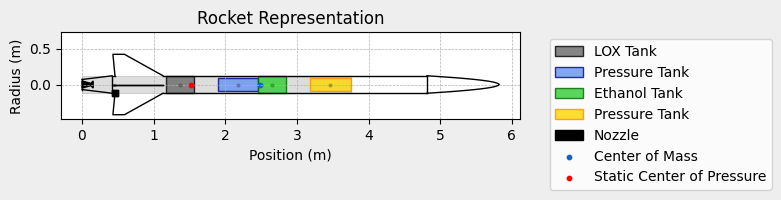

In [44]:
firehorn2.draw()

In [45]:
# https://docs.rocketpy.org/en/latest/reference/classes/Flight.html

flight = Flight(
    rocket=firehorn2,
    rail_length=ipt.l_rail,  
    environment=env,
    inclination=84,
    heading=144,
)

In [46]:
print(f"Impulse: {Total_impulse} [Ns]")
print(f"Burn time: {t_end:.3f} [s]")
print(f"Dry mass: {m_dry:.2f} [kg]")
print(f"Wet mass: {wet_mass:.2f} [kg]")
print(f"Wet mass at simulation start: {(m_wet - mass_lost_fuel_before_break - mass_lost_ox_before_break):.2f} [kg]")
print(f"Apogee (AGL): {flight.altitude(flight.apogee_time):.1f} [m]")
print(f"Time to apogee: {flight.apogee_time:.3f} [s]")
print(f"Max Mach: {flight.max_mach_number:.3f} [-]")
print(f"Max velocity: {flight.max_speed:.2f} [m/s]")
print(f"Max acceleration: {flight.max_acceleration:.2f} [m/s^2]")
print(f"Out of rail velocity: {flight.out_of_rail_velocity:.2f} [m/s]")
print(f"Out of rail time: {flight.out_of_rail_time:.3f} [s]")
flight.prints.out_of_rail_conditions()

Impulse: 36167 [Ns]
Burn time: 5.941 [s]
Dry mass: 95.66 [kg]
Wet mass: 124.30 [kg]
Wet mass at simulation start: 121.24 [kg]
Apogee (AGL): 3119.4 [m]
Time to apogee: 27.352 [s]
Max Mach: 0.734 [-]
Max velocity: 246.42 [m/s]
Max acceleration: 65.18 [m/s^2]
Out of rail velocity: 29.71 [m/s]
Out of rail time: 0.778 [s]

Rail Departure State

Rail Departure Time: 0.778 s
Rail Departure Velocity: 29.710 m/s
Rail Departure Stability Margin: 4.019 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 5.036
Rail Departure Reynolds Number: 4.774e+05


In [49]:
from excel_output import write_flight_outputs

# Path to the spreadsheet we want to write into
spreadsheet_path = "test_output_spreadsheet.xlsx"

# Row 0 of the DataFrames is Firehorn 1, which has no config_id — skip it.
if ipt.config_id is None:
    print("Skipping: this row is Firehorn 1 (reference data, no config_id).")
else:
    written = write_flight_outputs(
        filepath=spreadsheet_path,
        config_id=ipt.config_id,
        flight=flight,
        ipt=ipt,
    )

    print("\nWritten outputs:")
    for header, value in written.items():
        print(f"  {header}: {value:.3f}" if isinstance(value, float) else f"  {header}: {value}")


FileNotFoundError: [Errno 2] No such file or directory: 'test_output_spreadsheet.xlsx'